In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
import yfinance as yf

Data Collection

In [5]:
now = datetime.now()
start = datetime(now.year-10, now.month, now.day)
end = now
ticker = 'AAPL'
df = yf.download(ticker, start, end)
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
2016-05-26,22.858303,22.931151,22.455362,22.692118,225324800
2016-05-27,22.844637,22.871955,22.594223,22.637477,145364800
2016-05-31,22.733095,22.856026,22.496339,22.673906,169228800
2016-06-01,22.414381,22.660243,22.384787,22.541864,116693200
2016-06-02,22.245920,22.273237,21.997781,22.218602,160766400
...,...,...,...,...,...
2026-05-18,297.839996,300.660004,294.910004,300.239990,34483000
2026-05-19,298.970001,300.510010,296.350006,296.970001,42243600
2026-05-20,302.250000,302.799988,298.079987,298.179993,38229800


In [41]:
df = df.reset_index()
df

Price,level_0,index,Close,High,Low,Open,Volume,MA_100,MA_200,Percentage_Change
Ticker,,,AAPL,AAPL,AAPL,AAPL,AAPL,,,
0,0,2016-05-26,22.858303,22.931151,22.455362,22.692118,225324800,NaN,NaN,NaN
1,1,2016-05-27,22.844637,22.871955,22.594223,22.637477,145364800,NaN,NaN,-0.000598
2,2,2016-05-31,22.733095,22.856026,22.496339,22.673906,169228800,NaN,NaN,-0.004883
3,3,2016-06-01,22.414381,22.660243,22.384787,22.541864,116693200,NaN,NaN,-0.014020
4,4,2016-06-02,22.245920,22.273237,21.997781,22.218602,160766400,NaN,NaN,-0.007516
...,...,...,...,...,...,...,...,...,...,...
2507,2507,2026-05-18,297.839996,300.660004,294.910004,300.239990,34483000,265.337966,259.106732,-0.007961
2508,2508,2026-05-19,298.970001,300.510010,296.350006,296.970001,42243600,265.609117,259.593680,0.003794
2509,2509,2026-05-20,302.250000,302.799988,298.079987,298.179993,38229800,265.898595,260.092198,0.010971


Data Exploration & Visualization

Text(0, 0.5, 'Close_Price')

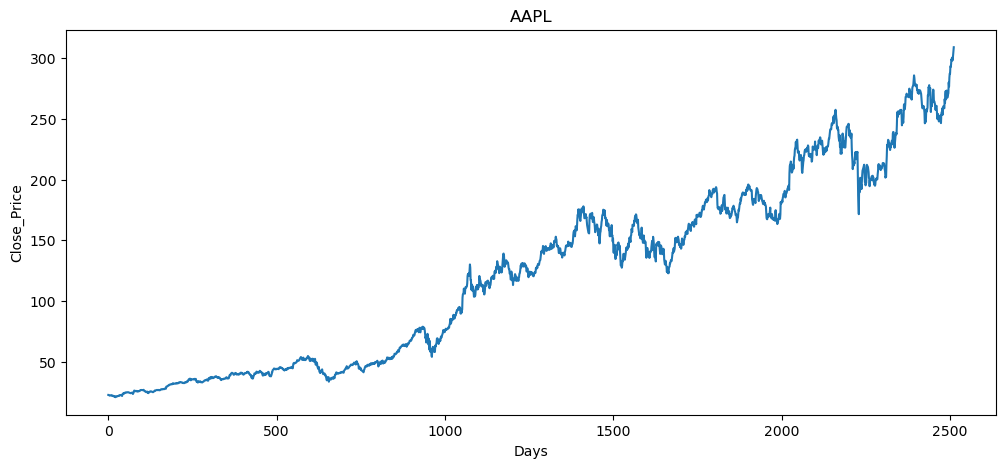

In [42]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.title(ticker)
plt.xlabel('Days')
plt.ylabel('Close_Price')

Feature Engineering

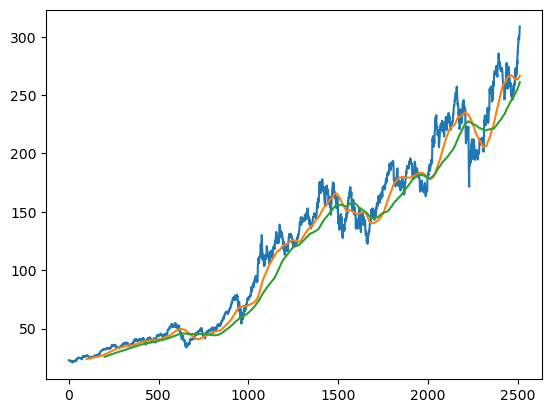

In [43]:
df['MA_100'] = df.Close.rolling(100).mean()
df['MA_200'] = df.Close.rolling(200).mean()
plt.plot(df.Close)
plt.plot(df.MA_100)
plt.plot(df.MA_200)

In [44]:
df['Percentage_Change'] = df.Close.pct_change()

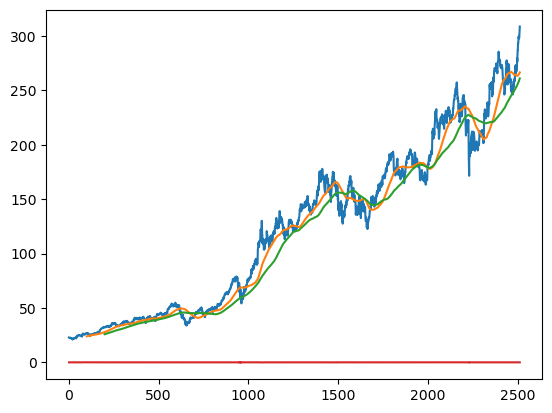

In [45]:
plt.plot(df.Close)
plt.plot(df.MA_100)
plt.plot(df.MA_200)
plt.plot(df.Percentage_Change)

Data Preprocessing

In [46]:
data_training = pd.DataFrame(df.Close[0:int(len(df)*0.7)])
data_testing = pd.DataFrame(df.Close[int(len(df)*0.7) : int(len(df))])

In [47]:
scaler = MinMaxScaler(feature_range=(0,1))

In [48]:
dt_array = scaler.fit_transform(data_training)
dt_array

array([[0.01213752],
       [0.01205047],
       [0.01133995],
       ...,
       [0.95135111],
       [0.96617641],
       [0.96686729]], shape=(1758, 1))

Sequence Creation

In [49]:
xtrain = []
ytrain = []
for i in range(100, dt_array.shape[0]):
    xtrain.append(dt_array[i-100:i])
    ytrain.append(dt_array[i,0])
xtrain, ytrain = np.array(xtrain), np.array(ytrain)

In [50]:
xtrain

array([[[0.01213752],
        [0.01205047],
        [0.01133995],
        ...,
        [0.03708496],
        [0.0380326 ],
        [0.03791599]],

       [[0.01205047],
        [0.01133995],
        [0.00930976],
        ...,
        [0.0380326 ],
        [0.03791599],
        [0.03779934]],

       [[0.01133995],
        [0.00930976],
        [0.00823667],
        ...,
        [0.03791599],
        [0.03779934],
        [0.03728909]],

       ...,

       [[0.71494266],
        [0.69477362],
        [0.69245623],
        ...,
        [0.95059705],
        [0.94745639],
        [0.94745639]],

       [[0.69477362],
        [0.69245623],
        [0.68099373],
        ...,
        [0.94745639],
        [0.94745639],
        [0.95135111]],

       [[0.69245623],
        [0.68099373],
        [0.65600183],
        ...,
        [0.94745639],
        [0.95135111],
        [0.96617641]]], shape=(1658, 100, 1))

In [51]:
ytrain

array([0.03779934, 0.03728909, 0.03720156, ..., 0.95135111, 0.96617641,
       0.96686729], shape=(1658,))

Building ML Model

In [6]:
import tensorflow as tf
from keras.layers import LSTM, Input, Dense
from keras.models import Sequential

In [53]:
model = Sequential()

model.add(Input(shape=(100,1)))
model.add(LSTM(units=128, activation='tanh', return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(25))
model.add(Dense(1))

Model Training

In [79]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(xtrain, ytrain, epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - loss: 0.0130
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - loss: 6.6948e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - loss: 7.1124e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 6.6608e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 6.0826e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - loss: 5.7748e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - loss: 5.9962e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 5.6688e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 5.7677e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 5.6677e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - loss: 4.9393e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 4.8240e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 4.5341e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - loss: 4.5709e-04
Epoch 15/50
52/52 ━

In [80]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [81]:
model.save('StockPredictionModelResult.keras')

Preparing Test Data

In [82]:
data_testing.tail(5)

Ticker,AAPL
2507,297.839996
2508,298.970001
2509,302.250000
2510,304.989990
2511,308.820007


In [83]:
past_100_days = data_training.tail(100)

In [84]:
past_100_days

Ticker,AAPL
1658,127.859947
1659,123.936546
1660,127.446953
1661,127.761589
1662,122.982704
...,...
1753,169.691086
1754,169.691086
1755,170.302505
1756,172.629883


In [85]:
final_df = pd.concat([past_100_days,data_testing], ignore_index = True)
final_df

Ticker,AAPL
0,127.859947
1,123.936546
2,127.446953
3,127.761589
4,122.982704
...,...
849,297.839996
850,298.970001
851,302.250000
852,304.989990


In [96]:
input_data = scaler.fit_transform(final_df)

In [97]:
input_data.shape

(854, 1)

In [98]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100: i])
    y_test.append(input_data[i, 0])

In [99]:
x_test, y_test = np.array(x_test), np.array(y_test)

In [100]:
x_test[0].shape
x_test

array([[[2.65021952e-02],
        [5.39575801e-03],
        [2.42804390e-02],
        ...,
        [2.54827370e-01],
        [2.67347794e-01],
        [2.67931266e-01]],

       [[5.39575801e-03],
        [2.42804390e-02],
        [2.59730649e-02],
        ...,
        [2.67347794e-01],
        [2.67931266e-01],
        [2.62838202e-01]],

       [[2.42804390e-02],
        [2.59730649e-02],
        [2.64442010e-04],
        ...,
        [2.67931266e-01],
        [2.62838202e-01],
        [2.48832339e-01]],

       ...,

       [[8.08927493e-01],
        [8.06726095e-01],
        [8.08659234e-01],
        ...,
        [9.53789015e-01],
        [9.40931626e-01],
        [9.47010631e-01]],

       [[8.06726095e-01],
        [8.08659234e-01],
        [8.05007529e-01],
        ...,
        [9.40931626e-01],
        [9.47010631e-01],
        [9.64655805e-01]],

       [[8.08659234e-01],
        [8.05007529e-01],
        [7.98456690e-01],
        ...,
        [9.47010631e-01],
        [9.6465

Making Prediction

In [102]:
y_predicted = model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step


In [103]:
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1,1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

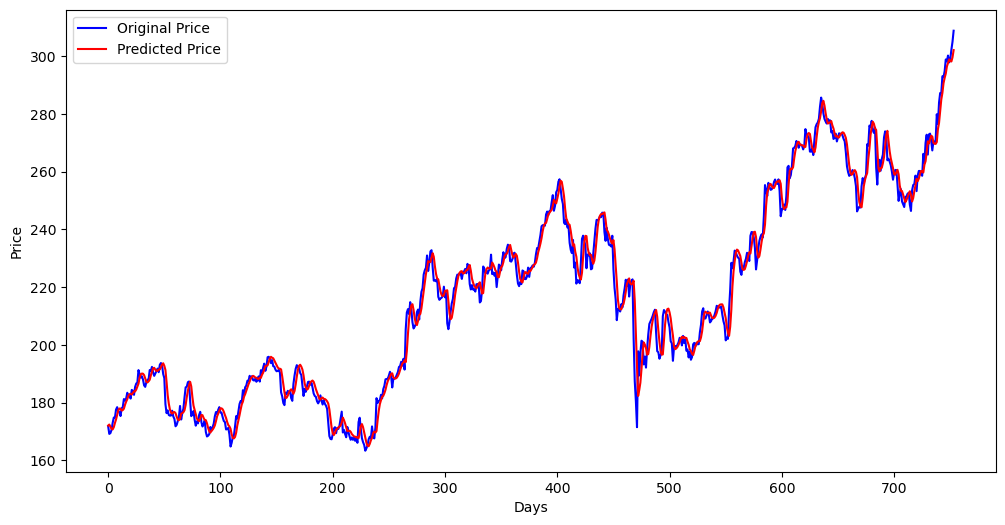

In [104]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend();

(140.0, 280.0)

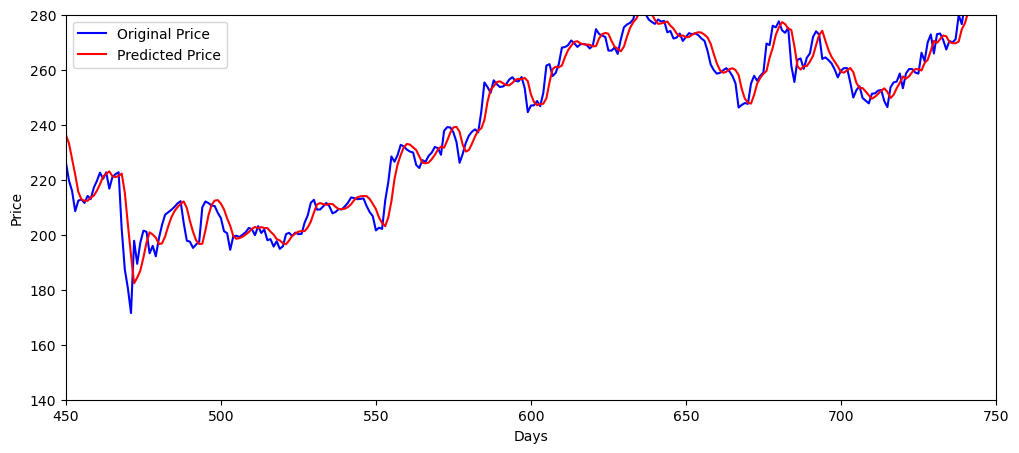

In [108]:
plt.figure(figsize=(12, 5))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.xlim(450, 750)
plt.ylim(140, 280)

Model Evaluation

In [109]:
from sklearn.metrics import mean_squared_error, r2_score

In [110]:
mse = mean_squared_error(y_test, y_predicted)
print(mse)

19.59749947879705


In [111]:
rmse = np.sqrt(mse)
print(rmse)

4.426906310144484


In [112]:
r2 = r2_score(y_test, y_predicted)
print(r2)

0.9834408555085986


In [1]:
print(jupyter__version__)

NameError: name 'jupyter__version__' is not defined

In [2]:
print(tensorflow__version__)

NameError: name 'tensorflow__version__' is not defined

In [3]:
tensorflow--version

NameError: name 'tensorflow' is not defined

In [8]:
print(tf.__version__)

2.21.0
